# 04 — LSS Architecture (Phase 4)

What this covers:
1. Depth bins — what D discrete depths look like
2. Lift output — frustum shape + depth distribution heatmap
3. Splat output — BEV feature map visualised as PCA projection
4. Shoot output — raw BEV logits before training
5. Full forward pass — shapes at each stage
6. Backward pass — confirm gradients flow

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt

from utils.config import LSS, BEV, CLASSES, SEGFORMER
from utils.device import get_device

device = get_device(verbose=True)
print('Ready')

[device] Using: mps
[device] Apple MPS backend active - M3 GPU will be used.
Ready


## 1. Depth bins

D = 41 bins  |  range: 1.0m → 60.0m  |  step: 1.48m
First 5 bins: [1.0, 2.4749999046325684, 3.950000047683716, 5.425000190734863, 6.900000095367432]
Last  5 bins: [54.099998474121094, 55.57500076293945, 57.04999923706055, 58.525001525878906, 60.0]


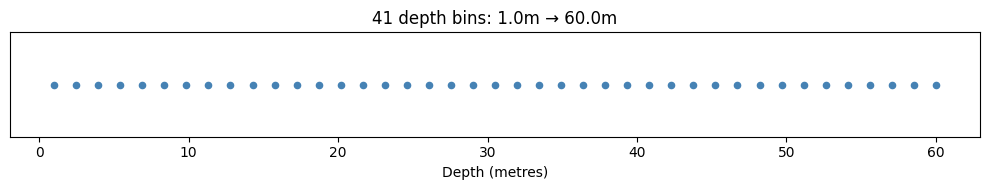

In [2]:
from models.lss.depth_bins import get_depth_bins, get_depth_bin_size

bins      = get_depth_bins()
bin_size  = get_depth_bin_size()

print(f'D = {BEV["d_bins"]} bins  |  range: {BEV["d_min"]}m → {BEV["d_max"]}m  |  step: {bin_size:.2f}m')
print(f'First 5 bins: {bins[:5].tolist()}')
print(f'Last  5 bins: {bins[-5:].tolist()}')

fig, ax = plt.subplots(figsize=(10, 2))
ax.scatter(bins.numpy(), np.zeros(len(bins)), s=20, color='steelblue')
ax.set_xlabel('Depth (metres)')
ax.set_title(f'{BEV["d_bins"]} depth bins: {BEV["d_min"]}m → {BEV["d_max"]}m')
ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Lift — frustum shape + depth distribution

In [3]:
from models.lss.lift import LiftModule

lift = LiftModule().to(device).eval()
n_params = sum(p.numel() for p in lift.parameters()) / 1e6
print(f'LiftModule parameters: {n_params:.1f}M')

x = torch.randn(1, 3, SEGFORMER['img_h'], SEGFORMER['img_w']).to(device)
with torch.no_grad():
    feats, depth = lift(x)

print(f'Input image    : {tuple(x.shape)}')
print(f'Frustum feats  : {tuple(feats.shape)}  (B, D, C, H\', W\')') 
print(f'Depth dist     : {tuple(depth.shape)}  (B, D, H\', W\')')
print(f'Depth sums to 1: {depth.sum(1).mean().item():.6f}')

LiftModule parameters: 4.7M
Input image    : (1, 3, 512, 1024)
Frustum feats  : (1, 41, 64, 16, 32)  (B, D, C, H', W')
Depth dist     : (1, 41, 16, 32)  (B, D, H', W')
Depth sums to 1: 1.000000


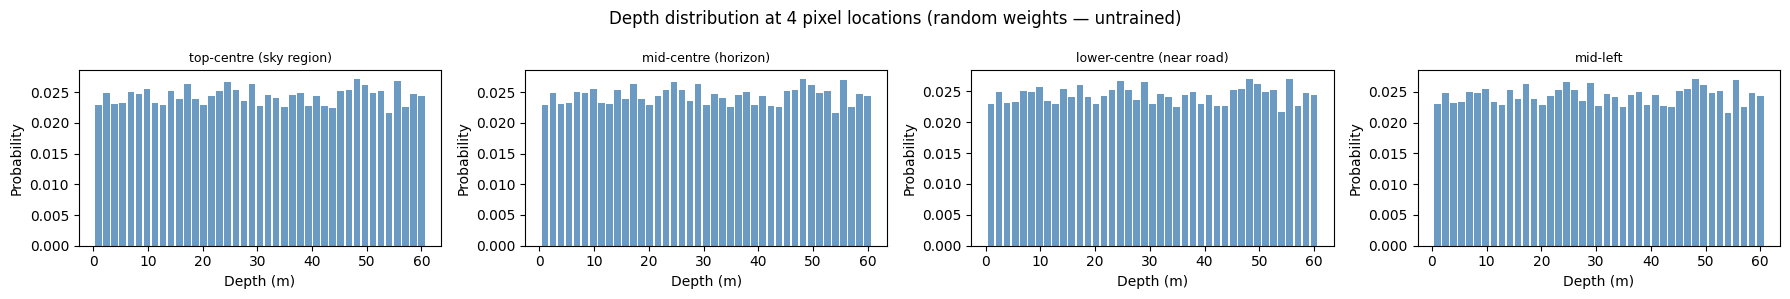

Note: distributions will become peaked/informative after training.


In [4]:
# visualise depth distribution at 4 pixel locations
depth_np = depth[0].cpu().numpy()   # (D, H', W')
H_, W_   = depth_np.shape[1], depth_np.shape[2]
bins_np  = get_depth_bins().numpy()

sample_pixels = [
    (H_//4,   W_//2,   'top-centre (sky region)'),
    (H_//2,   W_//2,   'mid-centre (horizon)'),
    (3*H_//4, W_//2,   'lower-centre (near road)'),
    (H_//2,   W_//4,   'mid-left'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
for ax, (row, col, label) in zip(axes, sample_pixels):
    dist = depth_np[:, row, col]
    ax.bar(bins_np, dist, width=1.2, color='steelblue', alpha=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Depth (m)')
    ax.set_ylabel('Probability')

plt.suptitle('Depth distribution at 4 pixel locations (random weights — untrained)')
plt.tight_layout(); plt.show()
print('Note: distributions will become peaked/informative after training.')

## 3. Splat — BEV feature map

BEV features: (1, 64, 200, 200)  (B, C, bev_size, bev_size)
Non-zero BEV cells: 3457 / 40000


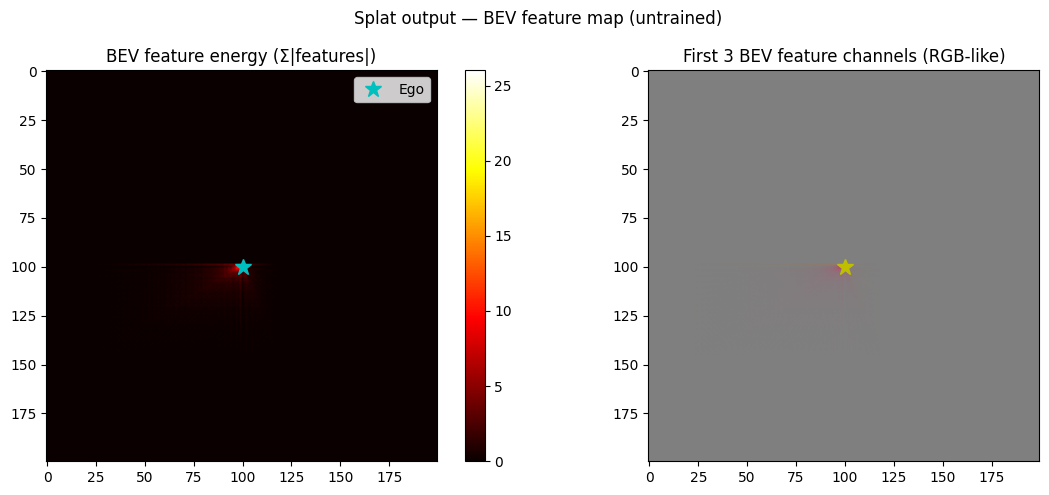

In [5]:
from models.lss.splat import SplatModule

splat = SplatModule().to(device).eval()

K = torch.tensor([[[1266.4, 0, 816.3],
                   [0, 1266.4, 491.5],
                   [0, 0, 1.0]]]).to(device)
T = torch.eye(4).unsqueeze(0).to(device)

with torch.no_grad():
    bev_feats = splat(feats, K, T)

print(f'BEV features: {tuple(bev_feats.shape)}  (B, C, bev_size, bev_size)')
print(f'Non-zero BEV cells: {(bev_feats[0].abs().sum(0) > 0).sum().item()} / {BEV["size"]**2}')

# visualise as energy map (sum of absolute feature values per cell)
energy = bev_feats[0].abs().sum(0).cpu().numpy()   # (200, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(energy, cmap='hot', origin='upper')
axes[0].plot(BEV['size']//2, BEV['size']//2, 'c*', markersize=12, label='Ego')
axes[0].set_title('BEV feature energy (Σ|features|)')
axes[0].legend()
plt.colorbar(im0, ax=axes[0])

# channel-wise mean across first 3 channels for quick RGB-like vis
rgb_bev = bev_feats[0, :3].permute(1,2,0).cpu().numpy()
rgb_bev = (rgb_bev - rgb_bev.min()) / (rgb_bev.max() - rgb_bev.min() + 1e-8)
axes[1].imshow(rgb_bev, origin='upper')
axes[1].plot(BEV['size']//2, BEV['size']//2, 'y*', markersize=12)
axes[1].set_title('First 3 BEV feature channels (RGB-like)')

plt.suptitle('Splat output — BEV feature map (untrained)')
plt.tight_layout(); plt.show()

## 4. Shoot — raw BEV logits

Logits shape: (1, 3, 200, 200)  (B, num_classes, bev_size, bev_size)
Logits range: [-0.031, 0.100]


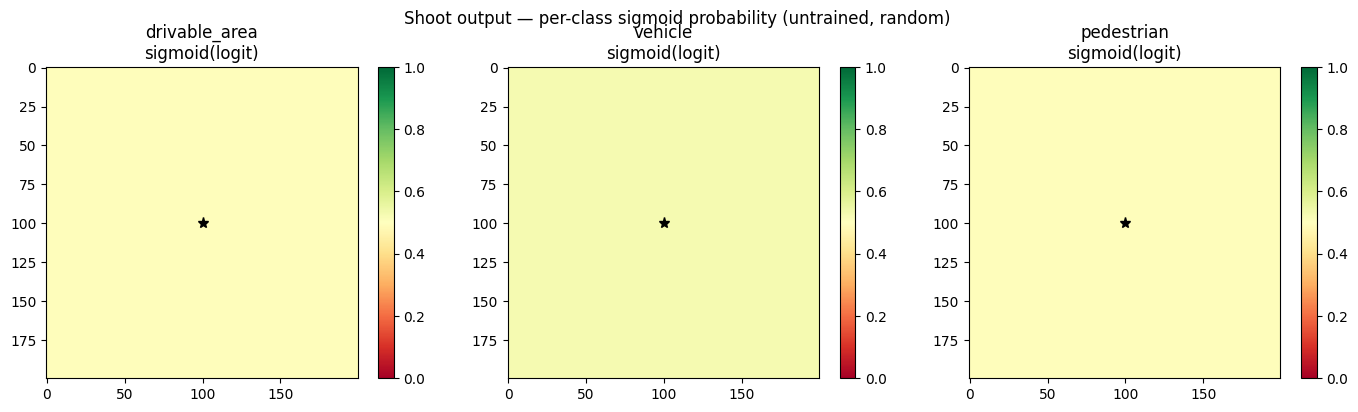

After training these maps will show road/vehicle/ped structure.


In [6]:
from models.lss.shoot import ShootModule

shoot = ShootModule().to(device).eval()

with torch.no_grad():
    logits = shoot(bev_feats)

print(f'Logits shape: {tuple(logits.shape)}  (B, num_classes, bev_size, bev_size)')
print(f'Logits range: [{logits.min().item():.3f}, {logits.max().item():.3f}]')

fig, axes = plt.subplots(1, CLASSES['num_classes'], figsize=(14, 4))
for i, (ax, name) in enumerate(zip(axes, CLASSES['names'])):
    logit_map = logits[0, i].cpu().numpy()
    prob_map  = torch.sigmoid(logits[0, i]).cpu().numpy()
    im = ax.imshow(prob_map, cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    ax.set_title(f'{name}\nsigmoid(logit)')
    ax.plot(100, 100, 'k*', markersize=8)
    plt.colorbar(im, ax=ax)

plt.suptitle('Shoot output — per-class sigmoid probability (untrained, random)')
plt.tight_layout(); plt.show()
print('After training these maps will show road/vehicle/ped structure.')

## 5. Full LSSModel — shapes at each stage

In [7]:
from models.lss.lss_model import LSSModel

model  = LSSModel().to(device).eval()
total  = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total parameters: {total:.1f}M')
print(f'  Lift  : {sum(p.numel() for p in model.lift.parameters())/1e6:.1f}M')
print(f'  Splat : {sum(p.numel() for p in model.splat.parameters())/1e6:.1f}M')
print(f'  Shoot : {sum(p.numel() for p in model.shoot.parameters())/1e6:.1f}M')

x = torch.randn(1, 3, SEGFORMER['img_h'], SEGFORMER['img_w']).to(device)
K = torch.tensor([[[1266.4, 0, 816.3],[0,1266.4,491.5],[0,0,1.0]]]).to(device)
T = torch.eye(4).unsqueeze(0).to(device)

with torch.no_grad():
    logits, depth_dist = model(x, K, T)

print(f'\nForward pass shapes:')
print(f'  Input image : {tuple(x.shape)}')
print(f'  Output logits: {tuple(logits.shape)}')
print(f'  Depth dist  : {tuple(depth_dist.shape)}')
assert tuple(logits.shape) == (1, CLASSES['num_classes'], BEV['size'], BEV['size'])
print(f'\nShape contract satisfied ✓')

Total parameters: 6.0M
  Lift  : 4.7M
  Splat : 0.0M
  Shoot : 1.2M

Forward pass shapes:
  Input image : (1, 3, 512, 1024)
  Output logits: (1, 3, 200, 200)
  Depth dist  : (1, 41, 16, 32)

Shape contract satisfied ✓


## 6. Backward pass — gradients flow check

In [8]:
model = LSSModel().to(device)
x     = torch.randn(1, 3, SEGFORMER['img_h'], SEGFORMER['img_w']).to(device)
K     = torch.tensor([[[1266.4,0,816.3],[0,1266.4,491.5],[0,0,1.0]]]).to(device)
T     = torch.eye(4).unsqueeze(0).to(device)

logits, _ = model(x, K, T)
gt        = torch.zeros_like(logits)
loss      = torch.nn.functional.binary_cross_entropy_with_logits(logits, gt)
loss.backward()

grad_norms = {name: p.grad.norm().item()
              for name, p in model.named_parameters()
              if p.grad is not None}

nan_params = [n for n, v in grad_norms.items() if v != v]
zero_params= [n for n, v in grad_norms.items() if v == 0]

print(f'Parameters with gradients: {len(grad_norms)}')
print(f'NaN gradients            : {len(nan_params)}')
print(f'Zero gradients           : {len(zero_params)}')
print(f'Loss                     : {loss.item():.4f}')

if not nan_params:
    print('\nBackward pass ✓ — gradients are clean and non-NaN.')
else:
    print(f'\nWARNING: NaN gradients in: {nan_params}')

Parameters with gradients: 234
NaN gradients            : 0
Zero gradients           : 0
Loss                     : 0.7325

Backward pass ✓ — gradients are clean and non-NaN.


## Summary

If all cells ran clean:
- LSSModel forward pass produces `(B, 3, 200, 200)` logits ✓
- Depth distributions sum to 1.0 ✓
- Gradients flow, no NaN ✓

Run verification:
```bash
python scripts/verify_phase4.py
```

The BEV maps (cell 4) look random because the model is untrained.
After Phase 5 training they will show road/vehicle structure.